In [1]:
from mlkem_gpu.reduce_gpu import barrett_reduce, montgomery_reduce

print("Barrett:")
print(barrett_reduce([3329, 3330, 5000, -1]))

print("Montgomery:")
print(montgomery_reduce([3329, 100000, -100000]))

Barrett:
tensor([    0,     1, -1658,    -1], device='mps:0', dtype=torch.int16)
Montgomery:
tensor([    0, -1333,  1333], device='mps:0', dtype=torch.int16)


In [2]:
import time
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

from mlkem_gpu.reduce_gpu import barrett_reduce, montgomery_reduce

In [4]:
### Available Devices
available_devices = ["cpu"]

if torch.backends.mps.is_available():
    available_devices.append("mps")

if torch.cuda.is_available():
    available_devices.append("cuda")

available_devices

['cpu', 'mps']

In [5]:
### Timing Helper
def sync_device(device: str):
    if device == "cuda":
        torch.cuda.synchronize()
    elif device == "mps":
        torch.mps.synchronize()


def benchmark_reduce_function(
    func,
    function_name: str,
    device: str,
    size: int,
    repeats: int = 100,
):
    # Create random integer coefficients
    x = torch.randint(
        low=-100000,
        high=100000,
        size=(size,),
        dtype=torch.int64,
        device=device,
    )

    # Warm-up
    for _ in range(10):
        _ = func(x)

    sync_device(device)

    start = time.perf_counter()

    for _ in range(repeats):
        y = func(x)

    sync_device(device)

    end = time.perf_counter()

    total_time = end - start
    avg_time_ms = (total_time / repeats) * 1000
    throughput = size / (avg_time_ms / 1000)

    return {
        "function": function_name,
        "device": device,
        "input_size": size,
        "repeats": repeats,
        "avg_time_ms": avg_time_ms,
        "throughput_coeffs_per_sec": throughput,
    }

In [6]:
### Run Benchmarks
sizes = [
    256,
    1024,
    4096,
    16384,
    65536,
    262144,
    1048576,
]

results = []

for device in available_devices:
    for size in sizes:
        results.append(
            benchmark_reduce_function(
                func=barrett_reduce,
                function_name="barrett_reduce",
                device=device,
                size=size,
                repeats=100,
            )
        )

        results.append(
            benchmark_reduce_function(
                func=montgomery_reduce,
                function_name="montgomery_reduce",
                device=device,
                size=size,
                repeats=100,
            )
        )

df = pd.DataFrame(results)
df

,function,device,input_size,repeats,avg_time_ms,throughput_coeffs_per_sec
0,barrett_reduce,cpu,256,100,0.370548,6.908688e+05
1,montgomery_reduce,cpu,256,100,0.318224,8.044654e+05
2,barrett_reduce,cpu,1024,100,0.300257,3.410411e+06
3,montgomery_reduce,cpu,1024,100,0.269840,3.794841e+06
4,barrett_reduce,cpu,4096,100,0.244764,1.673448e+07
5,montgomery_reduce,cpu,4096,100,0.253652,1.614813e+07
6,barrett_reduce,cpu,16384,100,0.240642,6.808452e+07
7,montgomery_reduce,cpu,16384,100,0.255448,6.413842e+07
8,barrett_reduce,cpu,65536,100,0.236481,2.771303e+08
9,montgomery_reduce,cpu,65536,100,0.285043,2.299163e+08


In [7]:
### Save Results
#output_path = Path("../results/timings/reduce_benchmark_mac.csv")
#output_path = Path("../results/timings/reduce_benchmark_windows.csv")

output_path.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(output_path, index=False)
output_path

PosixPath('../results/timings/reduce_benchmark_mac.csv')

In [10]:
from pathlib import Path
import pandas as pd

csv_file = output_path

df = pd.read_csv(csv_file)

print(f"Loaded: {csv_file}")
print(f"Rows: {len(df)}")

display(df.head())

Loaded: ../results/timings/reduce_benchmark_mac.csv
Rows: 28


,function,device,input_size,repeats,avg_time_ms,throughput_coeffs_per_sec
0,barrett_reduce,cpu,256,100,0.370548,6.908688e+05
1,montgomery_reduce,cpu,256,100,0.318224,8.044654e+05
2,barrett_reduce,cpu,1024,100,0.300257,3.410411e+06
3,montgomery_reduce,cpu,1024,100,0.269840,3.794841e+06
4,barrett_reduce,cpu,4096,100,0.244764,1.673448e+07


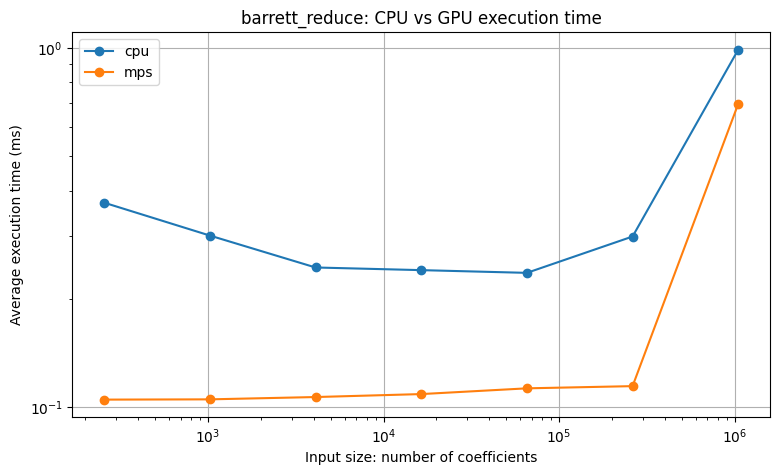

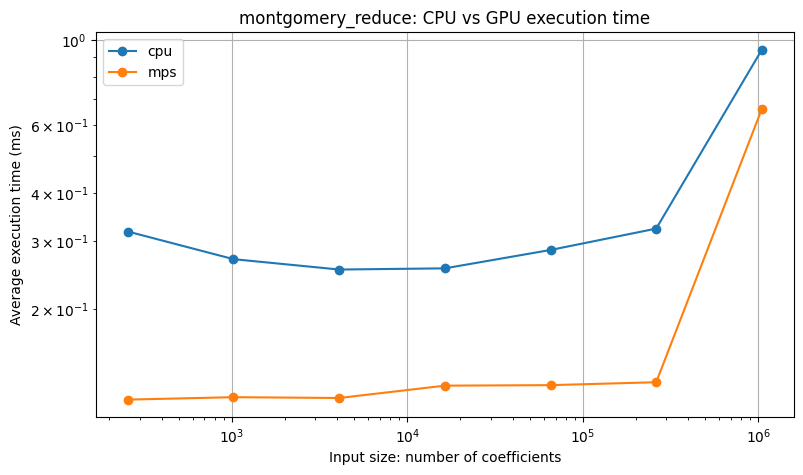

In [11]:
### Plot: Average Time
for function_name in df["function"].unique():
    subset = df[df["function"] == function_name]

    plt.figure(figsize=(9, 5))

    for device in subset["device"].unique():
        device_data = subset[subset["device"] == device]

        plt.plot(
            device_data["input_size"],
            device_data["avg_time_ms"],
            marker="o",
            label=device,
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Input size: number of coefficients")
    plt.ylabel("Average execution time (ms)")
    plt.title(f"{function_name}: CPU vs GPU execution time")
    plt.legend()
    plt.grid(True)
    plt.show()

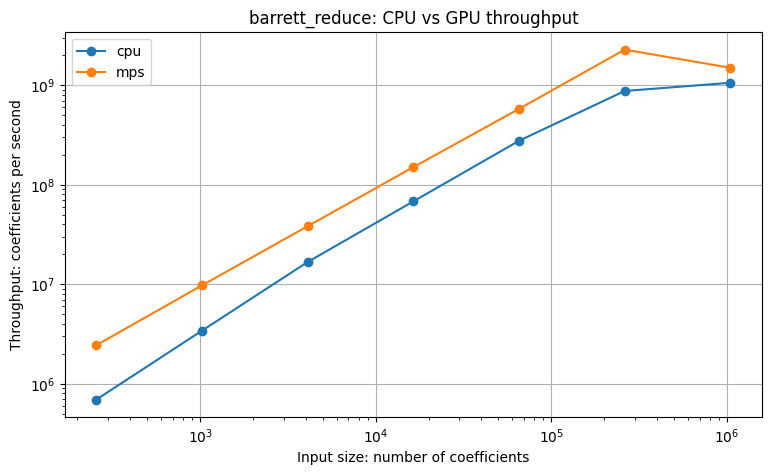

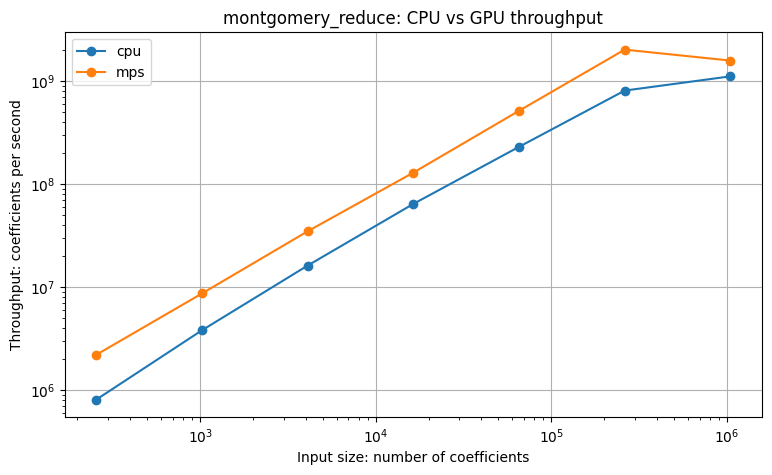

In [12]:
### Plot: Throughput
for function_name in df["function"].unique():
    subset = df[df["function"] == function_name]

    plt.figure(figsize=(9, 5))

    for device in subset["device"].unique():
        device_data = subset[subset["device"] == device]

        plt.plot(
            device_data["input_size"],
            device_data["throughput_coeffs_per_sec"],
            marker="o",
            label=device,
        )

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Input size: number of coefficients")
    plt.ylabel("Throughput: coefficients per second")
    plt.title(f"{function_name}: CPU vs GPU throughput")
    plt.legend()
    plt.grid(True)
    plt.show()